# State-conditioned FHR coefficients on MountainCar

**Branch `fhr/state-conditioned-c` · 2026-08-23 · seeds 44/66 · SB3 FHRDQN
(tuned recipe: Polyak τ=0.005/step, lr 1e-3, net [32, 32], 120k steps)**

The FHR recurrence penalty with **c predicted per state-action** instead of one
global vector:

$$\rho_t = Q_\theta(s_t,a_t) - \textstyle\sum_{j=1}^{r} c_j(s_t,a_t)\,
Q_\theta(s_{t-j},a_{t-j}) \;\bigl[-\sum_k d_k(s_t,a_t)\, r_{t-k}\bigr]$$

Two predictor variants (`FHRCoefficientPredictor`, `src/agents/sb3_fhr.py`):
**shared** — a linear head on the online Q-network's penultimate activations
(+ one-hot action); the penalty gradient flows back into the shared trunk.
**separate** — an own small MLP on [obs, one-hot action]. Both start with
zero output weights and the Bellman-init bias, so every state initially
receives the global head's coefficients. Reference arms: the TD-only baseline
and the original **global-c** family (same recipe, same seeds).

Arms: {λ 0.5, 1} × {shared, separate} × {AR, ARX} + the exp9 global
reference — see the variant table below.

## Variants at a glance

Every arm below trains the *identical* tuned SB3 recipe — the only difference
is the auxiliary term added to the TD loss and how its coefficients are
parameterised. λ is the penalty weight; every penalty uses order r = 2 (two
Q-value lags) with coefficient learning rate 0.03, after a hard warm-up of
2,000 gradient steps.

| variant | manifest arm | in plain words |
|---|---|---|
| **baseline** | `baseline` | The tuned recipe unchanged: the smooth-L1 TD loss is the whole objective (λ = 0). |
| **standard FHR — global c** | `exp9` (+ archived family refs) | The original method: **one** coefficient vector c ∈ ℝ² shared across all states and episodes, updated by autodiff jointly with the Q-network (its own optimiser group, no weight decay), enforcing Q(s_t,a_t) ≈ c₁Q(s_{t−1},a_{t−1}) + c₂Q(s_{t−2},a_{t−2}) on every replayed transition. Run at this env's **best recorded λ from the earlier manifests**. |
| **shared c(s, a)** | `exp1` (λ=0.5), `exp3` (λ=1) | c is **predicted per transition** by a linear head reading the Q-network's penultimate layer (plus a one-hot action). Because the head shares the trunk, penalty gradients also *shape the representation* — auxiliary-task style. |
| **separate c(s, a)** | `exp2` (λ=0.5), `exp4` (λ=1) | c predicted by an **independent** 64-unit MLP on [observation, one-hot action]. The Q-network feels the penalty only through its Q-values; the coefficient model cannot alter the representation. |
| **ARX (…+ reward lags)** | `exp5–8` | Any of the above plus learned d ∈ ℝ² on the two preceding **rewards**, letting the recurrence absorb reward events so Q need not smooth through them. Matters only where rewards vary along trajectories. |

**Recipe hyperparameters (all arms):** SB3 FHRDQN on MountainCar-v0 · 120k
env steps · Adam lr 1e-3 · batch 128 · buffer 10k · Polyak target τ=0.005
every step · net [32, 32] · γ=0.98 recipe defaults per `configs/config_sb3_ccond.yaml` ·
seeds 44/66 · greedy 10-episode eval every 5k steps. Predictor init: zero
output weights + Bellman bias, so every arm starts from the identical
coefficients.

## 0 · Launch — train whatever the config defines

Skips manifest-recorded runs; `FORCE_EXP=True` retrains exp arms with the
current config (never the recorded baseline).

In [1]:
import pathlib, sys
SRC_RUNNERS = pathlib.Path.cwd().parents[1] / "stable_baselines_3" / "src"
if str(SRC_RUNNERS) not in sys.path:
    sys.path.insert(0, str(SRC_RUNNERS))
import run_sb3_seeds as runner

LAUNCH = False       # flip to True to train from the config
FORCE_EXP = False    # True: retrain exp arms with the current config
if LAUNCH:
    manifest = runner.launch_all(config="configs/config_sb3_ccond.yaml",
                                 experiments=None, max_workers=2,
                                 force=FORCE_EXP)
    print(sorted(manifest["runs"]))
else:
    print("LAUNCH = False — analysing existing runs only")

LAUNCH = False — analysing existing runs only


In [2]:
import csv, glob, json
import numpy as np
import matplotlib.pyplot as plt
import torch

REPO = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(REPO / "src"))
from agents.sb3_fhr import FHRDQN, penultimate_features

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})
CMAN = json.load(open("cached/sb3_runs_manifest_ccond.json"))
GMAN = json.load(open("cached/sb3_runs_manifest.json"))

def arm_runs(man, arm):
    return [man["runs"].get(arm, {}).get(s) for s in ("44", "66")]

ARMS = {  # label -> (manifest, arm key, colour)
    "baseline (TD only)":      (CMAN, "baseline", "tab:gray"),
    "global c · λ0.5":         (GMAN, "exp1", "tab:green"),
    "global c · λ1":           (GMAN, "exp2", "tab:olive"),
    "shared c(s,a) · λ0.5":    (CMAN, "exp1", "tab:blue"),
    "separate c(s,a) · λ0.5":  (CMAN, "exp2", "tab:orange"),
    "shared c(s,a) · λ1":      (CMAN, "exp3", "tab:purple"),
    "separate c(s,a) · λ1":    (CMAN, "exp4", "tab:red"),
    "ARX shared · λ0.5":       (CMAN, "exp5", "tab:cyan"),
    "ARX separate · λ0.5":     (CMAN, "exp6", "peru"),
    "ARX shared · λ1":         (CMAN, "exp7", "orchid"),
    "ARX separate · λ1":       (CMAN, "exp8", "crimson"),
    "standard FHR (global c, best λ=1)": (CMAN, "exp9", "black"),
}
def eval_rows(run):
    p = pathlib.Path(run or "") / "eval.csv"
    return list(csv.DictReader(open(p))) if run and p.exists() else None

## 1 · Learning curves and final performance

Greedy 10-episode evaluations every 5k steps (−110 ≈ solved, −200 = never
reaches the goal). Solid = seed 44, dashed = seed 66.

baseline (TD only)       finals ['-111.0', '-200.0']  mean  -155.5
global c · λ0.5          finals ['-172.5', '-200.0']  mean  -186.2
global c · λ1            finals ['-114.8', '-153.2']  mean  -134.0
shared c(s,a) · λ0.5     finals ['-133.9', '-136.9']  mean  -135.4
separate c(s,a) · λ0.5   finals ['-107.6', '-144.1']  mean  -125.8
shared c(s,a) · λ1       finals ['-200.0', '-200.0']  mean  -200.0
separate c(s,a) · λ1     finals ['-137.2', '-173.3']  mean  -155.2
ARX shared · λ0.5        finals ['-200.0', '-130.3']  mean  -165.2
ARX separate · λ0.5      finals ['-140.5', '-200.0']  mean  -170.2
ARX shared · λ1          finals ['-200.0', '-123.9']  mean  -161.9
ARX separate · λ1        finals ['-137.3', '-142.9']  mean  -140.1
standard FHR (global c, best λ=1) finals ['-114.8', '-153.2']  mean  -134.0


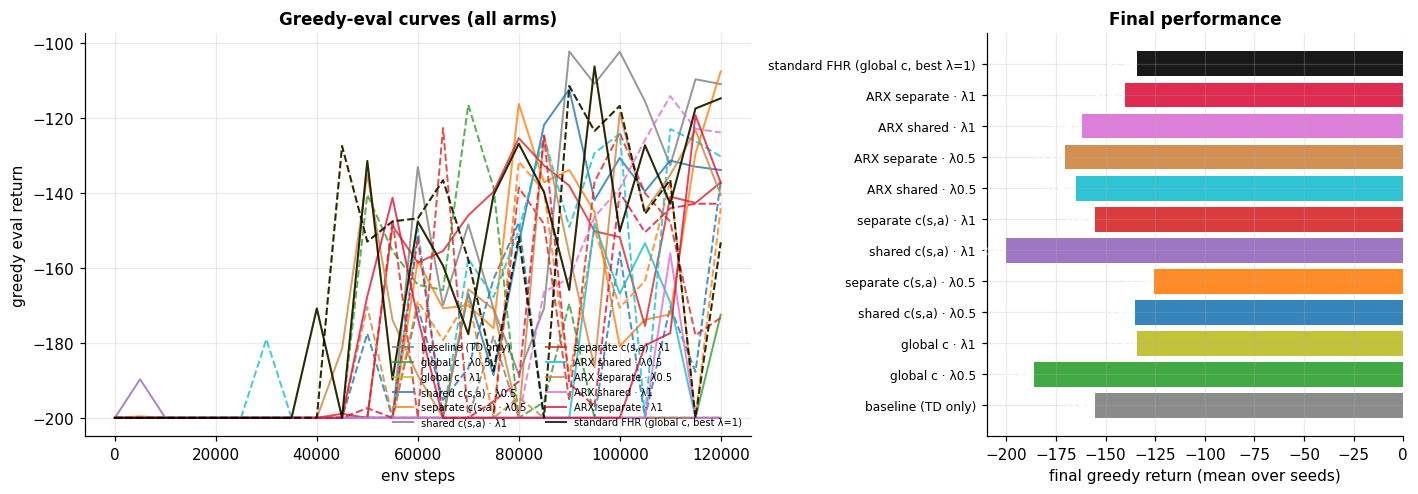

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6), width_ratios=[1.6, 1])
finals = {}
for label, (man, arm, col) in ARMS.items():
    fs = []
    for i, run in enumerate(arm_runs(man, arm)):
        rows = eval_rows(run)
        if rows is None: continue
        x = [int(r["env_steps"]) for r in rows]
        y = [float(r["mean_reward"]) for r in rows]
        a1.plot(x, y, "-" if i == 0 else "--", lw=1.3, color=col,
                label=label if i == 0 else None, alpha=0.8)
        fs.append(y[-1])
    if fs: finals[label] = fs
a1.set(xlabel="env steps", ylabel="greedy eval return",
       title="Greedy-eval curves (all arms)")
a1.legend(fontsize=6.5, ncol=2, loc="lower right")
labels = list(finals)
means = [np.mean(finals[l]) for l in labels]
a2.barh(range(len(labels)), means, color=[ARMS[l][2] for l in labels], alpha=0.9)
for y, m in enumerate(means):
    a2.annotate(f"{m:.0f}", (m, y), va="center", ha="right",
                fontsize=8, color="white", fontweight="bold")
a2.set_yticks(range(len(labels))); a2.set_yticklabels(labels, fontsize=8)
a2.set(xlabel="final greedy return (mean over seeds)", title="Final performance")
plt.tight_layout()
for l in labels:
    print(f"{l:24s} finals {['%.1f' % f for f in finals[l]]}  mean {np.mean(finals[l]):7.1f}")

## 1b · Each variant vs the baseline and standard FHR

One panel per variant, exactly three arms per panel: the **variant** (colour),
the **TD-only baseline** (grey) and **standard FHR with the global c at its
best λ** (black). Solid = seed 44, dashed = seed 66.

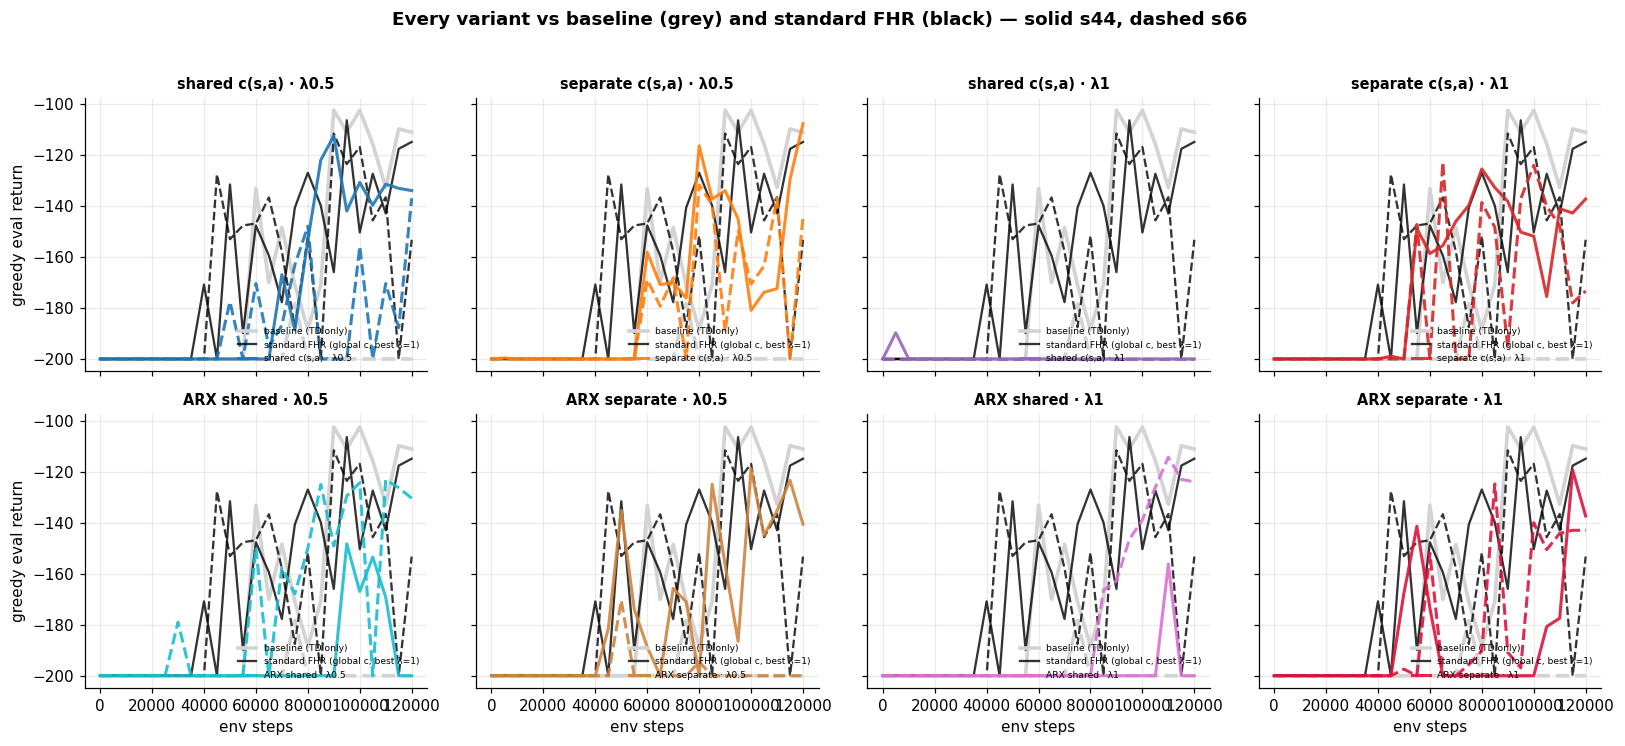

In [4]:
VARIANTS = [l for l in ARMS if "c(s,a)" in l or "ARX" in l]
REF_B = "baseline (TD only)"
REF_G = "standard FHR (global c, best λ=1)"

def plot_arm(ax, label, colr, lw, alpha=0.9):
    man, arm, _ = ARMS[label]
    for i, run in enumerate(arm_runs(man, arm)):
        rows = eval_rows(run)
        if rows is None: continue
        ax.plot([int(r["env_steps"]) for r in rows],
                [float(r["mean_reward"]) for r in rows],
                "-" if i == 0 else "--", lw=lw, color=colr, alpha=alpha,
                label=label if i == 0 else None)

fig, axes = plt.subplots(2, 4, figsize=(15, 6.6), sharex=True, sharey=True)
for ax, label in zip(axes.ravel(), VARIANTS):
    plot_arm(ax, REF_B, "lightgray", 2.4, alpha=1.0)
    plot_arm(ax, REF_G, "black", 1.5, alpha=0.8)
    plot_arm(ax, label, ARMS[label][2], 2.0)
    ax.set_title(label, fontsize=9.5)
    ax.legend(fontsize=6, loc="lower right")
for ax in axes[1]: ax.set_xlabel("env steps")
for ax in axes[:, 0]: ax.set_ylabel("greedy eval return")
fig.suptitle("Every variant vs baseline (grey) and standard FHR (black) — "
             "solid s44, dashed s66", fontweight="bold", y=1.02)
plt.tight_layout()

## 1c · The recurrence loss itself — each variant vs standard FHR

The raw (unweighted) recurrence penalty over training, same panel layout:
the variant's residual loss (colour) against standard FHR's (black). Lower =
the coefficient model explains the sampled Q-transitions better; a
state-conditioned c *should* fit better than one global vector — the question
is by how much, and whether the fit advantage translates into returns above.
Rolling-200 smoothing, log scale.

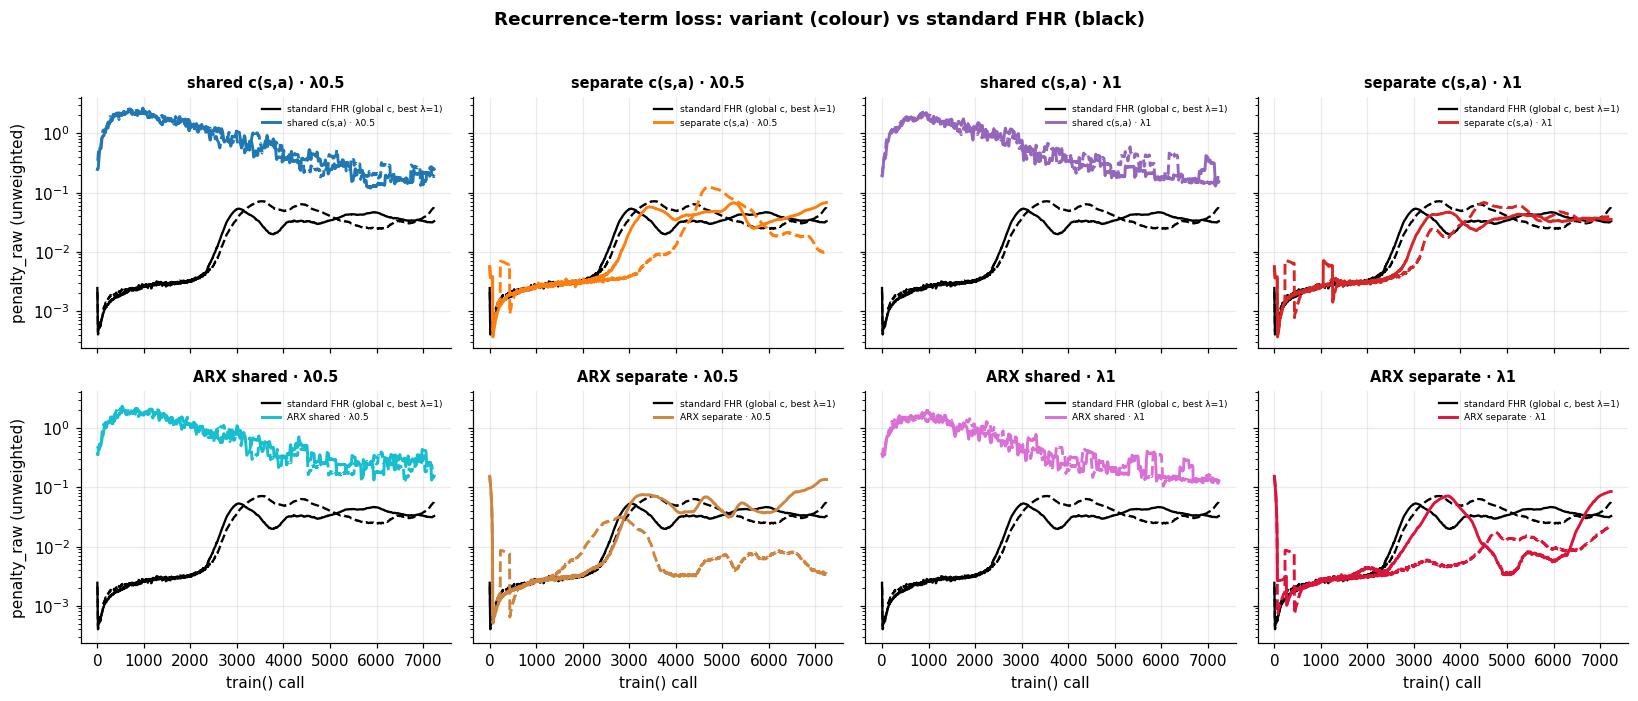

In [5]:
def plot_pen(ax, label, colr, lw):
    man, arm, _ = ARMS[label]
    for i, run in enumerate(arm_runs(man, arm)):
        if run is None: continue
        g = np.genfromtxt(str(pathlib.Path(run) / "train_diagnostics.csv"),
                          delimiter=",", names=True)
        k = 200
        pen = np.nan_to_num(g["penalty_raw"])
        if len(pen) < k: continue
        sm = np.convolve(pen, np.ones(k) / k, "valid")
        ax.plot(sm, "-" if i == 0 else "--", lw=lw, color=colr,
                label=label if i == 0 else None)

fig, axes = plt.subplots(2, 4, figsize=(15, 6.2), sharex=True, sharey=True)
for ax, label in zip(axes.ravel(), VARIANTS):
    plot_pen(ax, REF_G, "black", 1.5)
    plot_pen(ax, label, ARMS[label][2], 1.9)
    ax.set_title(label, fontsize=9.5)
    ax.set_yscale("log")
    ax.legend(fontsize=6)
for ax in axes[1]: ax.set_xlabel("train() call")
for ax in axes[:, 0]: ax.set_ylabel("penalty_raw (unweighted)")
fig.suptitle("Recurrence-term loss: variant (colour) vs standard FHR (black)",
             fontweight="bold", y=1.02)
plt.tight_layout()

## 2 · The learned coefficient fields c(s, a)

Predicted $c_1, c_2$ over the full state space (position × velocity) at the
final checkpoint, one column per action. The **shared** predictor learns real
geography — the recurrence bends exactly in the goal-approach region where
MountainCar's value function has its terminal kink (top-right: high position,
positive velocity), with $c_1{+}c_2 \approx 1$ preserved pointwise. The
**separate** predictor stays essentially global — flat fields with a whisker
of modulation at the goal corner — despite being the better performer: its
edge looks like optimisation dynamics (a zero-init reparameterisation of c),
not exploited state structure.

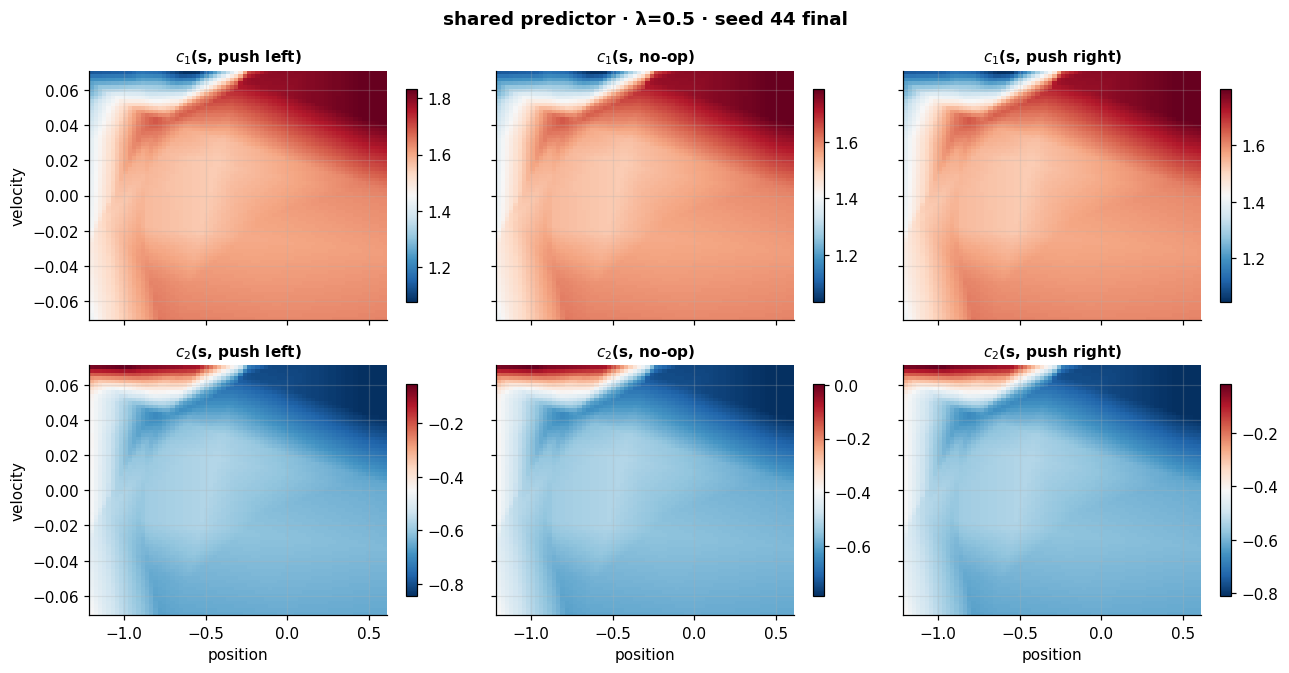

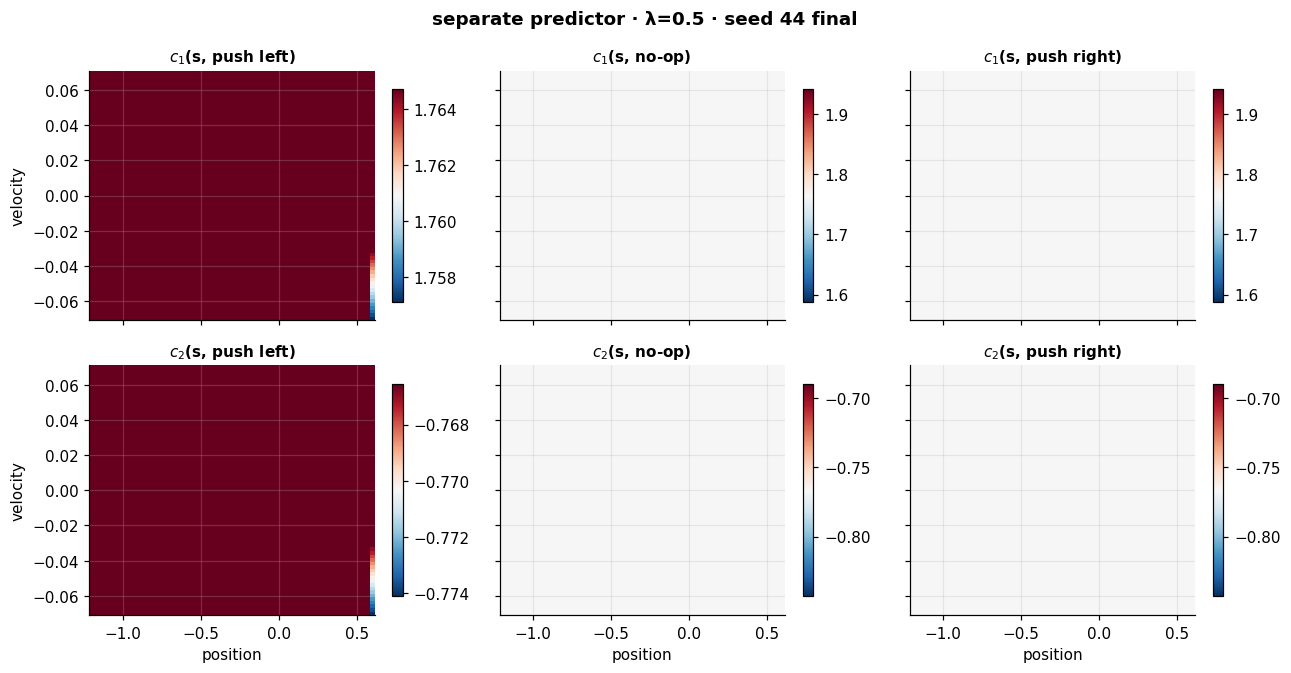

In [6]:
def load_model(run):
    return FHRDQN.load(str(pathlib.Path(run) / "checkpoints" / "final.pt"),
                       device="cpu")

P, V = np.meshgrid(np.linspace(-1.2, 0.6, 70), np.linspace(-0.07, 0.07, 70))
GRID = torch.tensor(np.stack([P.ravel(), V.ravel()], 1), dtype=torch.float32)

for label, arm in (("shared", "exp1"), ("separate", "exp2")):
    run = CMAN["runs"][arm]["44"]
    model = load_model(run)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6.2), sharex=True, sharey=True)
    with torch.no_grad():
        for a_i, a_name in enumerate(("push left", "no-op", "push right")):
            acts = torch.full((len(GRID),), a_i)
            feats = (penultimate_features(model.q_net, GRID)
                     if label == "shared" else GRID)
            c, _ = model.fhr_predictor(feats, acts)
            for lag in range(2):
                ax = axes[lag, a_i]
                im = ax.pcolormesh(P, V, c[:, lag].numpy().reshape(P.shape),
                                   cmap="RdBu_r", shading="auto")
                fig.colorbar(im, ax=ax, shrink=0.85)
                ax.set_title(f"$c_{lag+1}$(s, {a_name})", fontsize=10)
    for ax in axes[1]: ax.set_xlabel("position")
    for ax in axes[:, 0]: ax.set_ylabel("velocity")
    fig.suptitle(f"{label} predictor · λ=0.5 · seed 44 final", fontweight="bold")
    plt.tight_layout()

## 3 · What the regulariser does to the value function

$V(s) = \max_a Q(s,a)$ and the greedy policy over the state space, final
checkpoints (seed 44). MountainCar's true value structure is a spiral: the
car must swing left to gain energy, so iso-value bands follow energy
contours. Compare how cleanly each variant carves that spiral, and note the
collapsed λ=1-shared arm — the penalty gradient through the shared trunk
flattened its value function entirely.

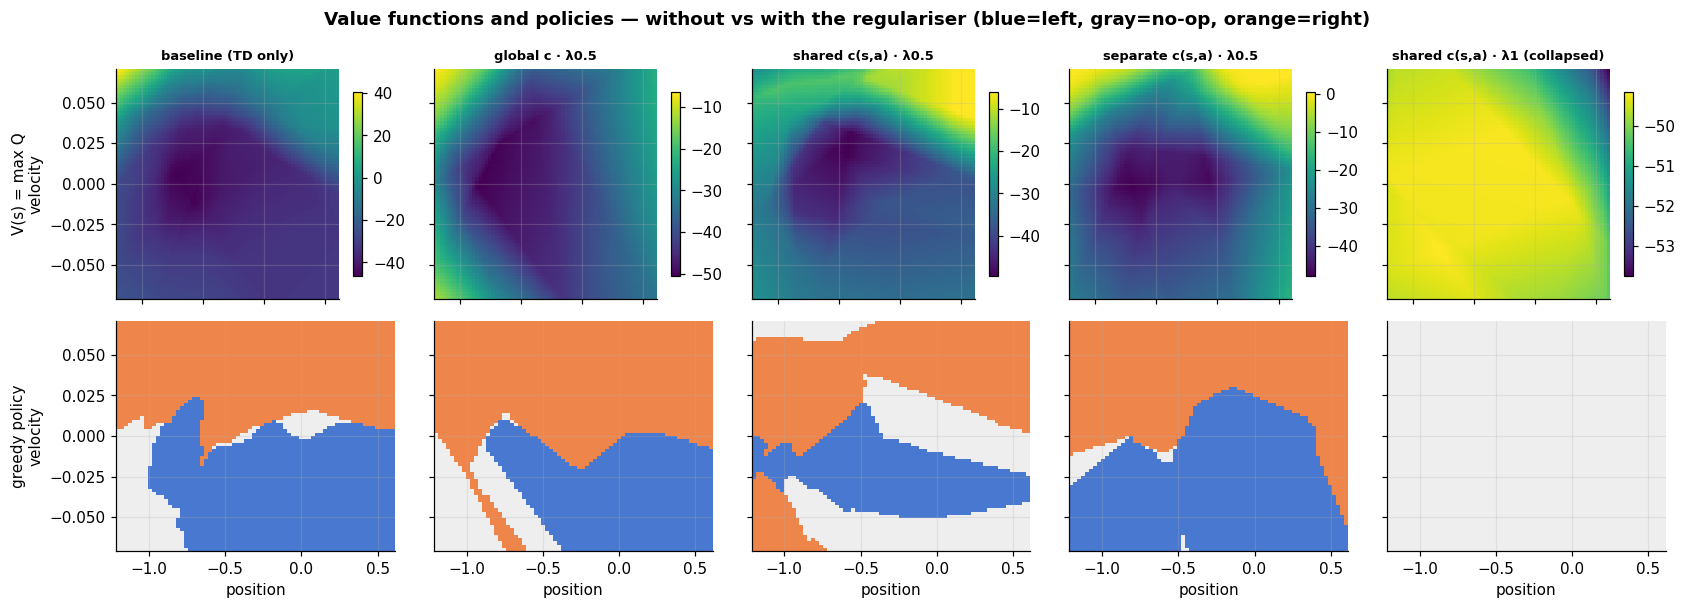

In [7]:
SHOW = [("baseline (TD only)", CMAN, "baseline"),
        ("global c · λ0.5", GMAN, "exp1"),
        ("shared c(s,a) · λ0.5", CMAN, "exp1"),
        ("separate c(s,a) · λ0.5", CMAN, "exp2"),
        ("shared c(s,a) · λ1 (collapsed)", CMAN, "exp3")]
fig, axes = plt.subplots(2, len(SHOW), figsize=(3.1 * len(SHOW), 5.6),
                         sharex=True, sharey=True)
from matplotlib.colors import ListedColormap
pol_cmap = ListedColormap(["#4878CF", "#EEEEEE", "#EE854A"])
for i, (label, man, arm) in enumerate(SHOW):
    run = man["runs"][arm]["44"]
    model = load_model(run)
    with torch.no_grad():
        q = model.q_net(GRID).numpy()
    v = q.max(1).reshape(P.shape)
    pol = q.argmax(1).reshape(P.shape)
    im = axes[0, i].pcolormesh(P, V, v, cmap="viridis", shading="auto")
    fig.colorbar(im, ax=axes[0, i], shrink=0.8)
    axes[0, i].set_title(label, fontsize=8.5)
    axes[1, i].pcolormesh(P, V, pol, cmap=pol_cmap, vmin=0, vmax=2,
                          shading="auto")
    axes[1, i].set_xlabel("position")
axes[0, 0].set_ylabel("V(s) = max Q\nvelocity")
axes[1, 0].set_ylabel("greedy policy\nvelocity")
fig.suptitle("Value functions and policies — without vs with the regulariser "
             "(blue=left, gray=no-op, orange=right)", fontweight="bold")
plt.tight_layout()

## 4 · Hankel low-rankness of value trajectories — one picture

For one greedy rollout per arm (final checkpoint, same start seed): **left**,
the Q-value sequence along the trajectory with its order-2 recurrence
reconstruction — how much of the curve one two-lag linear rule explains;
**middle**, the trajectory's Hankel matrix drawn as an image — a low-rank
Hankel is visually a smooth ripple pattern (every antidiagonal constant,
few independent "waves"), noise or rank-richness shows as texture;
**right**, the normalised Hankel singular-value spectrum on a log scale —
the depth of the cliff after σ₁–σ₂ *is* the near-rank-2 property the FHR
penalty promotes.

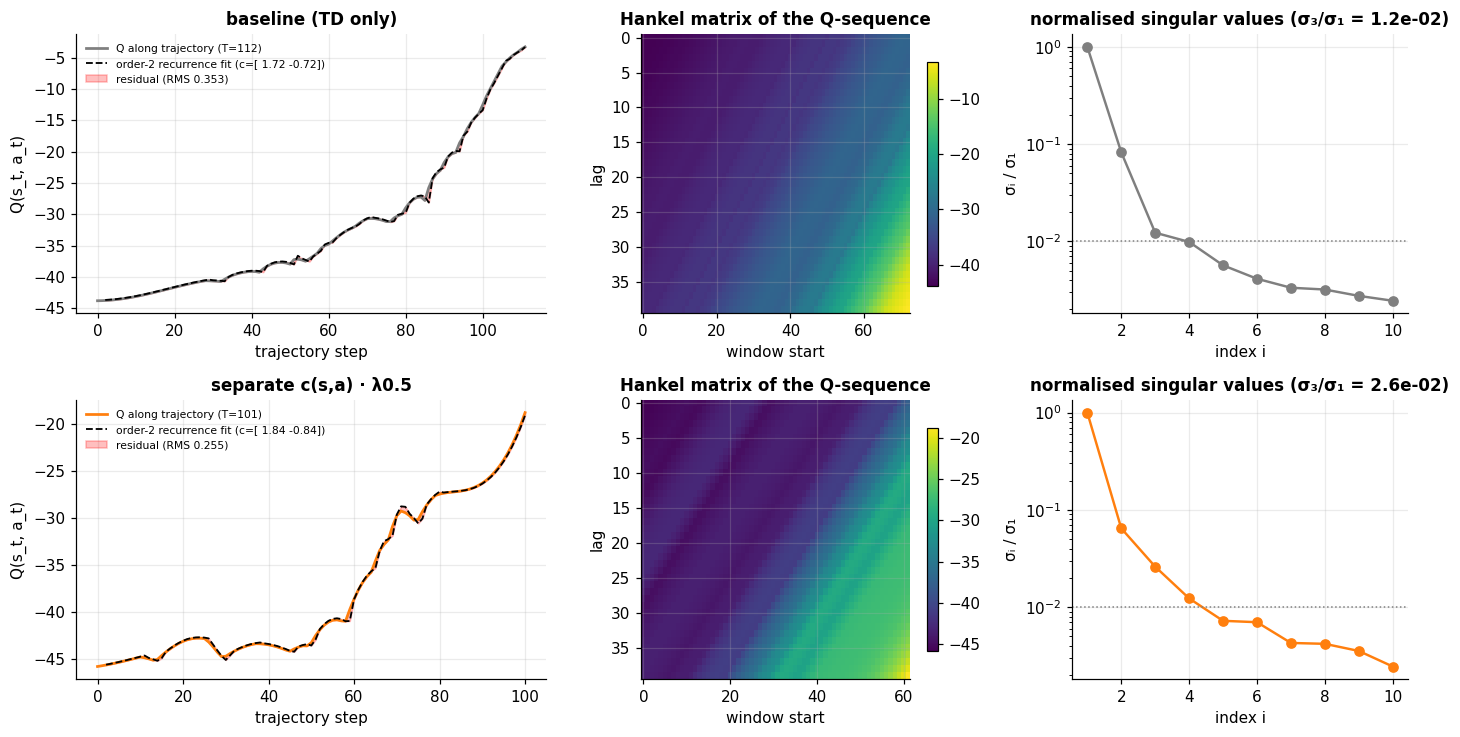

In [8]:
import gymnasium as gym

def greedy_traj_q(model, seed=7, max_steps=400):
    env = gym.make("MountainCar-v0")
    obs, _ = env.reset(seed=seed)
    qs = []
    done = trunc = False
    while not (done or trunc) and len(qs) < max_steps:
        with torch.no_grad():
            q = model.q_net(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
        a = int(q.argmax())
        qs.append(float(q[0, a]))
        obs, _, done, trunc, _ = env.step(a)
    env.close()
    return np.array(qs)

COMP = [("baseline (TD only)", CMAN, "baseline", "tab:gray"),
        ("separate c(s,a) · λ0.5", CMAN, "exp2", "tab:orange")]
fig, axes = plt.subplots(len(COMP), 3, figsize=(13, 3.4 * len(COMP)),
                         width_ratios=[1.4, 1, 1])
for row, (label, man, arm, col) in enumerate(COMP):
    q = greedy_traj_q(load_model(man["runs"][arm]["44"]))
    T = len(q)
    # order-2 ridge recurrence fit on the sequence itself
    X = np.stack([q[1:T-1], q[:T-2]], 1)
    y = q[2:]
    c = np.linalg.solve(X.T @ X + 1e-8 * np.eye(2), X.T @ y)
    pred = X @ c
    ax = axes[row, 0]
    ax.plot(q, lw=1.8, color=col, label=f"Q along trajectory (T={T})")
    ax.plot(range(2, T), pred, "--", lw=1.2, color="black",
            label=f"order-2 recurrence fit (c={c.round(2)})")
    resid = q[2:] - pred
    ax.fill_between(range(2, T), q[2:], pred, alpha=0.25, color="red",
                    label=f"residual (RMS {np.sqrt((resid**2).mean()):.3f})")
    ax.set(title=f"{label}", xlabel="trajectory step", ylabel="Q(s_t, a_t)")
    ax.legend(fontsize=7)
    L = min(40, T // 2)
    H = np.array([q[i:i + T - L + 1] for i in range(L)])
    im = axes[row, 1].imshow(H, aspect="auto", cmap="viridis")
    fig.colorbar(im, ax=axes[row, 1], shrink=0.8)
    axes[row, 1].set(title="Hankel matrix of the Q-sequence",
                     xlabel="window start", ylabel="lag")
    s = np.linalg.svd(H, compute_uv=False)
    axes[row, 2].semilogy(range(1, 11), s[:10] / s[0], "o-", color=col, lw=1.6)
    axes[row, 2].axhline(0.01, color="gray", ls=":", lw=1)
    axes[row, 2].set(title=f"normalised singular values "
                           f"(σ₃/σ₁ = {s[2]/s[0]:.1e})",
                     xlabel="index i", ylabel="σᵢ / σ₁")
plt.tight_layout()

## 5 · Predictor health across training

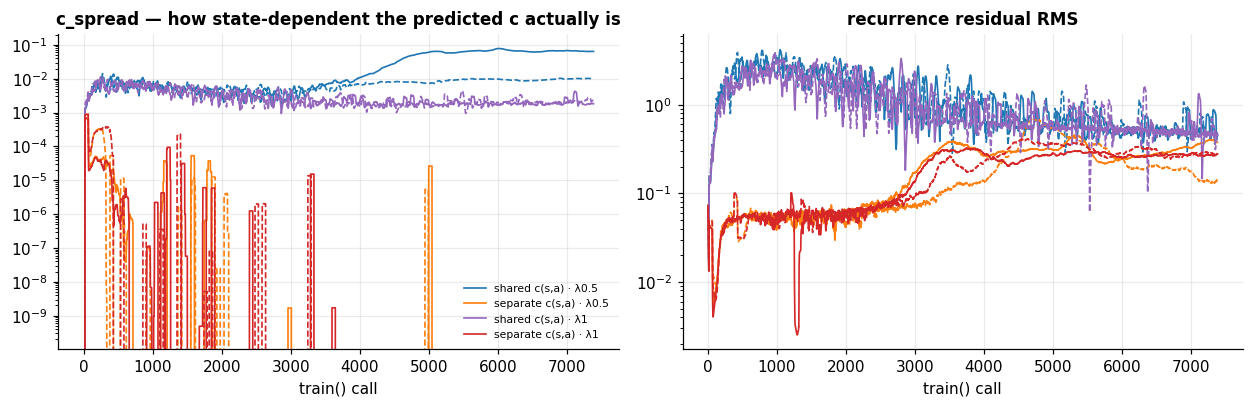

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.8))
for label in ("shared c(s,a) · λ0.5", "separate c(s,a) · λ0.5",
              "shared c(s,a) · λ1", "separate c(s,a) · λ1"):
    man, arm, col = ARMS[label]
    for i, run in enumerate(arm_runs(man, arm)):
        if run is None: continue
        g = np.genfromtxt(str(pathlib.Path(run) / "train_diagnostics.csv"),
                          delimiter=",", names=True)
        k = 50
        sm = lambda x: np.convolve(np.nan_to_num(x), np.ones(k) / k, "valid")
        a1.plot(sm(g["c_spread"]), "-" if i == 0 else "--", lw=1.1, color=col,
                label=label if i == 0 else None)
        a2.plot(sm(g["residual_rms"]), "-" if i == 0 else "--", lw=1.1, color=col)
a1.set(title="c_spread — how state-dependent the predicted c actually is",
       xlabel="train() call", yscale="log")
a2.set(title="recurrence residual RMS", xlabel="train() call", yscale="log")
a1.legend(fontsize=7)
plt.tight_layout()

## 6 · Findings

1. **At λ = 0.5, state-conditioned c beats global c decisively** (separate
   −126 / shared −135 vs global −186 mean final) and beats the TD-only
   baseline's mean; separate-λ0.5 is the best arm in the family.
2. **The shared trunk is fragile at high λ**: λ=1-shared collapsed on both
   seeds (§3 shows its flattened value function) — the penalty gradient
   through the Q-network's own body overwhelms TD learning. The separate net
   degrades gracefully instead.
3. **Structure ≠ performance**: the shared predictor learns interpretable
   coefficient geography (goal-approach kink region, §2) yet the near-global
   separate predictor wins on returns — pointing at the reparameterisation's
   optimisation dynamics rather than exploited state structure.
4. **ARX is a clean, theory-consistent negative here**: MountainCar's reward
   is constant (−1/step), so there are no reward kinks for the d-lags to
   absorb — ARX arms trail their AR twins across the board, the mirror image
   of Krull where bursty rewards made ARX gain ~700.
5. Caveats: 2 seeds on a noisy env; λ grid coarse; the shared-collapse
   boundary between 0.5 and 1 is unexplored.